In [144]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [145]:
df = pd.read_csv('dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv')

In [146]:
def display_info(df):
    print(
        f"{'Column':<25} | {'Type':<15} | {'Unique':<7} | {'NaN':<5} | {'Details':<50}"
    )
    print("-" * 110)

    for col in df.columns:
        col_type = str(df[col].dtype)
        n_unique = df[col].nunique()
        n_nan = df[col].isna().sum()
        if isinstance(df[col].dtype, object) and n_unique <= 15:
            values = ", ".join(map(str, df[col].unique()[:5]))
            if n_unique > 15:
                values += f"... (+{n_unique - 15} more)"
            print(
                f"{col:<25} | {col_type:<15} | {n_unique:<7} | {n_nan:<5} | Values: {values}"
            )
        else:
            min_val = df[col].min()
            max_val = df[col].max()
            print(
                f"{col:<25} | {col_type:<15} | {n_unique:<7} | {n_nan:<5} | min: {min_val:>10} | max: {max_val:>10}"
            )
        print("-" * 110)

In [147]:
display_info(df)

Column                    | Type            | Unique  | NaN   | Details                                           
--------------------------------------------------------------------------------------------------------------
Age                       | int64           | 43      | 0     | min:         18 | max:         60
--------------------------------------------------------------------------------------------------------------
Attrition                 | str             | 2       | 0     | Values: Yes, No
--------------------------------------------------------------------------------------------------------------
BusinessTravel            | str             | 3       | 0     | Values: Travel_Rarely, Travel_Frequently, Non-Travel
--------------------------------------------------------------------------------------------------------------
DailyRate                 | int64           | 886     | 0     | min:        102 | max:       1499
------------------------------------------------

## Data Cleaning
    Turn all categorical Column into number

In [148]:
df["Attrition"] = df["Attrition"].map({"Yes": 1, "No": 0})
df["BusinessTravel"] = df["BusinessTravel"].map(
    {"Non-Travel": 0, "Travel_Rarely": 1, "Travel_Frequently": 2}
)
df["Department"] = df["Department"].map(
    {"Sales": 0, "Research & Development": 1, "Human Resources": 2}
)
df["EducationField"] = df["EducationField"].map(
    {
        "Life Sciences": 0,
        "Medical": 1,
        "Marketing": 2,
        "Technical Degree": 3,
        "Human Resources": 4,
        "Other": 5,
    }
)
df["Gender"] = df["Gender"].map({"Male": 0, "Female": 1})
df["JobRole"] = df["JobRole"].map(
    {
        "Sales Executive": 0,
        "Research Scientist": 1,
        "Laboratory Technician": 2,
        "Manufacturing Director": 3,
        "Healthcare Representative": 4,
        "Manager": 5,
        "Sales Representative": 6,
        "Research Director": 7,
        "Human Resources": 8,
    }
)
df["MaritalStatus"] = df["MaritalStatus"].map(
    {"Single": 0, "Married": 1, "Divorced": 2}
)
df["OverTime"] = df["OverTime"].map({"No": 0, "Yes": 1})

In [149]:
display_info(df)

Column                    | Type            | Unique  | NaN   | Details                                           
--------------------------------------------------------------------------------------------------------------
Age                       | int64           | 43      | 0     | min:         18 | max:         60
--------------------------------------------------------------------------------------------------------------
Attrition                 | int64           | 2       | 0     | Values: 1, 0
--------------------------------------------------------------------------------------------------------------
BusinessTravel            | int64           | 3       | 0     | Values: 1, 2, 0
--------------------------------------------------------------------------------------------------------------
DailyRate                 | int64           | 886     | 0     | min:        102 | max:       1499
----------------------------------------------------------------------------------------

In [150]:
df = df.drop(columns=["EmployeeNumber", "EmployeeCount", "Over18", "StandardHours"])

## Data Split
    Train 90%, Test 10%

In [151]:
from sklearn.model_selection import train_test_split

In [152]:
X = df["Attrition"]
y = df.drop(columns=["Attrition"])

In [153]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

### 1. Observe the histogram for Age, MonthlyIncome and DistanceFromHome. How many bins have zero counts? Do you think this is a good discretization? Why?

In [154]:
def plot_histograms(data, columns, bins=20, figsize=(15, 4)):
    fig, axes = plt.subplots(1, len(columns), figsize=figsize)
    
    for idx, col in enumerate(columns):
        axes[idx].hist(data[col], bins=bins, edgecolor='black')
        axes[idx].set_title(f'{col} Distribution')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()

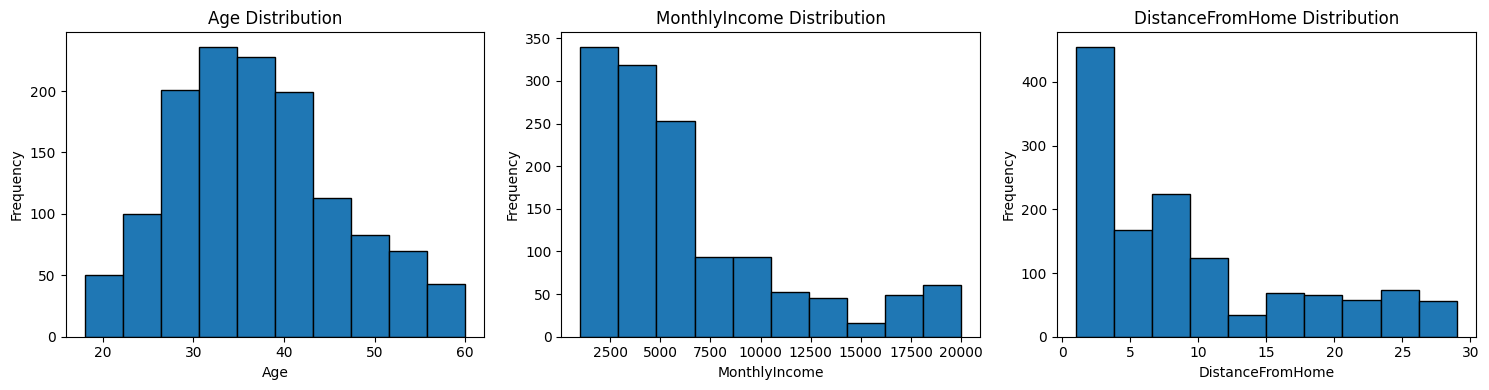

In [155]:
plot_histograms(y_train, ['Age', 'MonthlyIncome', 'DistanceFromHome'], bins=10)

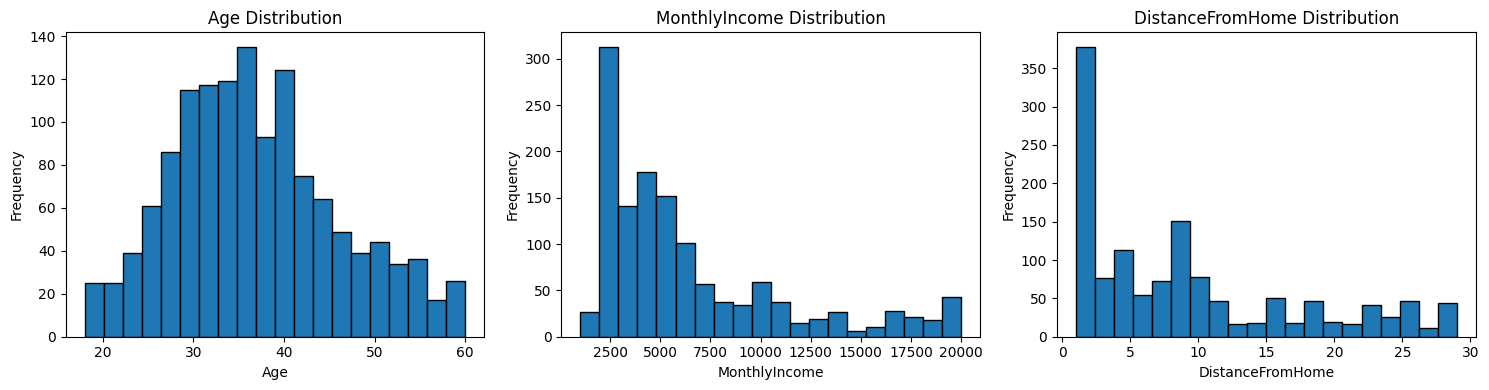

In [156]:
plot_histograms(y_train, ['Age', 'MonthlyIncome', 'DistanceFromHome'], bins=20)

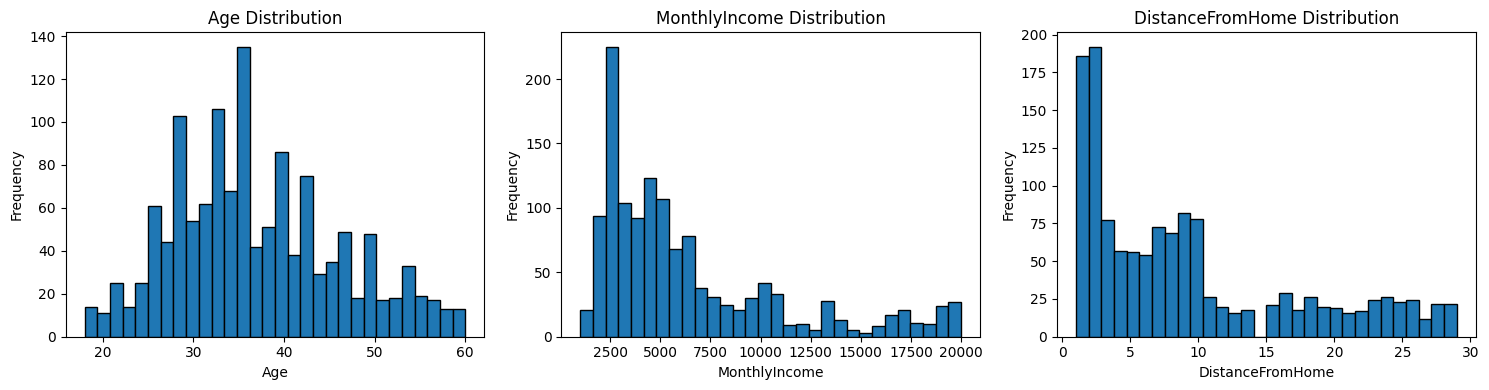

In [157]:
plot_histograms(y_train, ['Age', 'MonthlyIncome', 'DistanceFromHome'], bins=30)

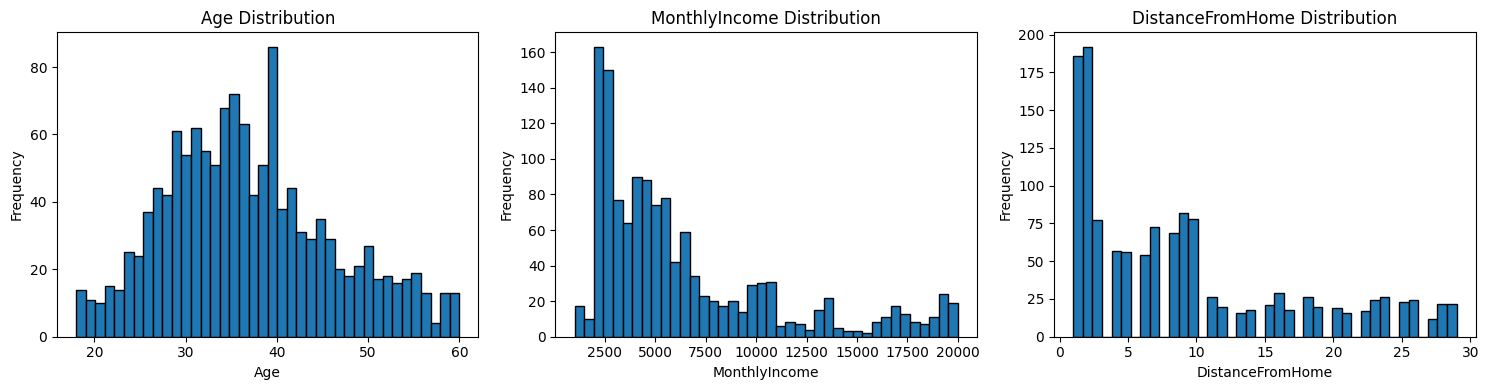

In [158]:
plot_histograms(y_train, ['Age', 'MonthlyIncome', 'DistanceFromHome'], bins=40)

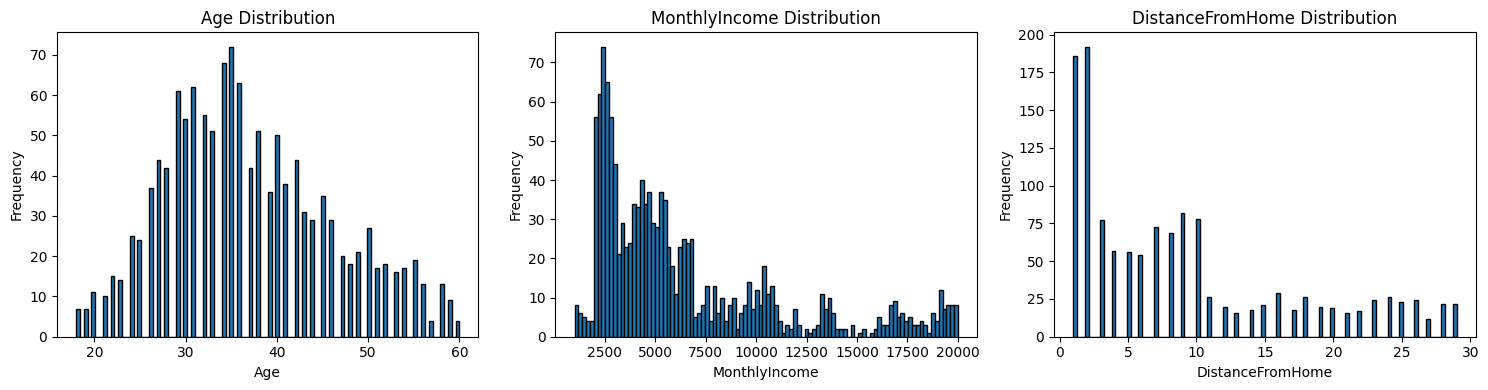

In [159]:
plot_histograms(y_train, ['Age', 'MonthlyIncome', 'DistanceFromHome'], bins=100)

### 2. Can we use a Gaussian to estimate this histogram? Why? What about a Gaussian Mixture Model (GMM)?